<div>
<h1>Linear Regression - Supervised Learning Algorithm</h1>
<span>Written by: Imad El Maftouhi</span>
</div>

Note: This notebook is more of a practical example on linear regression applied on a dataset for a specific target.

# Introduction

What is Linear Regression ? 
"Linear Regression is a fundamental supervised learning algorithm used to model the relationship between a dependent variable and one or more independent variables. It predicts continuous values by fitting a straight line that best represents the data.

It assumes that there is a linear relationship between the input and output
Uses a best‑fit line to make predictions
Commonly used in forecasting, trend analysis, and predictive modelling ". [geeksforgeeks - Linear Regression in Machine Learning](https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/)

The core hypothesis is that the expected value of the response is a **linear function** of the inputs:

$$\mathbb{E}[y \mid \mathbf{x}] = f(\mathbf{x}) = \mathbf{x}^\top \boldsymbol{\beta}$$

---

# Load prerequisites

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
# set a random seed for deterministic and reproducible random number generation.
np.random.seed(42) # This sets the global random state for the numpy.random module. All subsequent random calls will use this seed.

# Defining the problem

**Advertising Dataset**

This dataset contains data about the sales of a product in relation to the advertising budgets spent on TV, radio and newspaper. It's commonly used to explore the relationship between advertising efforts and sales.

- Labels: Continuous values representing sales of the product (in thousands of units).
- Size: 200 samples each with 4 attributes.
- Data: Numerical data

In [13]:
df = pd.read_csv("../datasets/advertising.csv")

print(f"Shape of dataset : {df.shape}")

Shape of dataset : (200, 4)


In [14]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Goal : Use linear regression to predict sales based on the advertising budgets spents  across the three sectors. 
Sucess Criteria : >90% accuracy.

## Data exploration and preprocessing

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [17]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [30]:
#check missing values
df.isna().sum()
# df.isna().mean()*100
# df.isna().sum()[df.isna().sum() > 0]


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [21]:
print(f"Number of duplicates entries across columns = {df.duplicated().sum()}")
for col in df.columns:
    print(f"Number of duplicates for {col} = {df[col].duplicated().sum()}")

Number of duplicates entries across columns = 0
Number of duplicates for TV = 10
Number of duplicates for Radio = 33
Number of duplicates for Newspaper = 28
Number of duplicates for Sales = 79


Duplicates enties for columns may be natural, the issue resides of a full entry is duplicated across all columns. In this case we don't have any.

In [ ]:
# boundaries of data
for col in df.columns:
    print(f"Range of '{col}' : Min = {df[col].min():.4f} | Max = {df[col].max():.4f} | Avg = {df[col].mean():.4f}")

Range of 'TV' : Min = 0.7000 | Max = 296.4000 | Avg = 147.0425
Range of 'Radio' : Min = 0.0000 | Max = 49.6000 | Avg = 23.2640
Range of 'Newspaper' : Min = 0.3000 | Max = 114.0000 | Avg = 30.5540
Range of 'Sales' : Min = 1.6000 | Max = 27.0000 | Avg = 15.1305


In [38]:
# detect outliers : comparse against the spread of the data. Standard method is IQR rule.
for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col:10s} | min={df[col].min():.2f} max={df[col].max():.2f} | Q1 = {Q1} Q3 = {Q3} | outliers={n_outliers}")

TV         | min=0.70 max=296.40 | Q1 = 74.375 Q3 = 218.825 | outliers=0
Radio      | min=0.00 max=49.60 | Q1 = 9.975 Q3 = 36.525 | outliers=0
Newspaper  | min=0.30 max=114.00 | Q1 = 12.75 Q3 = 45.1 | outliers=2
Sales      | min=1.60 max=27.00 | Q1 = 11.0 Q3 = 19.05 | outliers=0


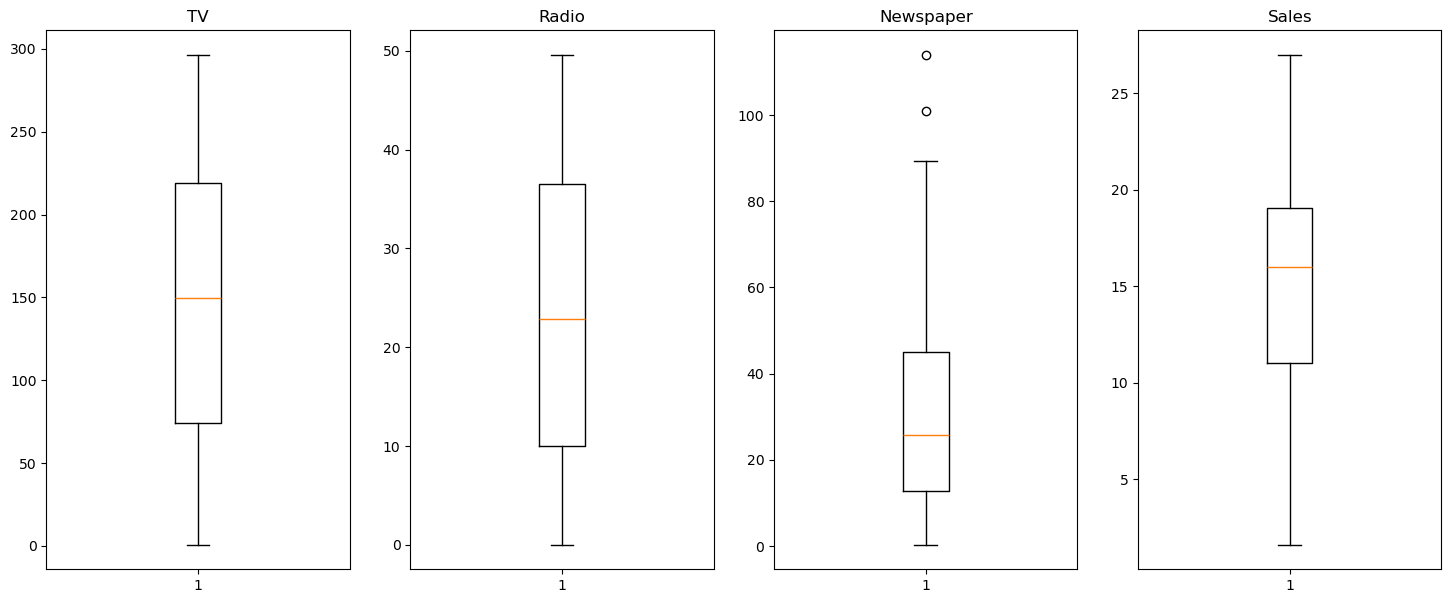

In [35]:
fix, axes = plt.subplots(1,4, figsize=(18,7))
axes = axes.flatten()
for i, col in enumerate(df.select_dtypes(include="number").columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.show()


In [43]:
df[df["Newspaper"] > df["Newspaper"].quantile(.75) + 1.5 * (df["Newspaper"].quantile(.75) - df["Newspaper"].quantile(.25))]

,TV,Radio,Newspaper,Sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8


In [48]:
# a key thing to note : Should we actually drop outliers in this case ? Dropping is not always the right call.
# Are they data errors ? Are they legitimate but extreme values ? 

df.drop(index=[16,101], inplace=True, errors="ignore")
df.reset_index(drop=True, inplace=True)

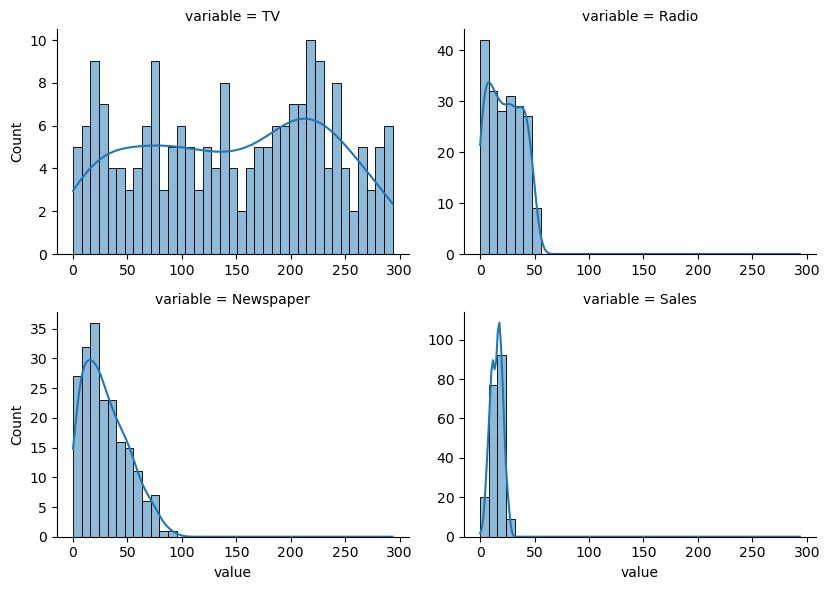

In [56]:
melted = df.select_dtypes(include="number").melt() # converts the wide dataframe into a long one with two columns; variable and value

sns.displot(
    data=melted,
    x="value",
    col="variable",
    col_wrap=2,
    kde=True,
    height=3,
    aspect=1.4,
    facet_kws={"sharey": False, "sharex": False}
)

plt.show()

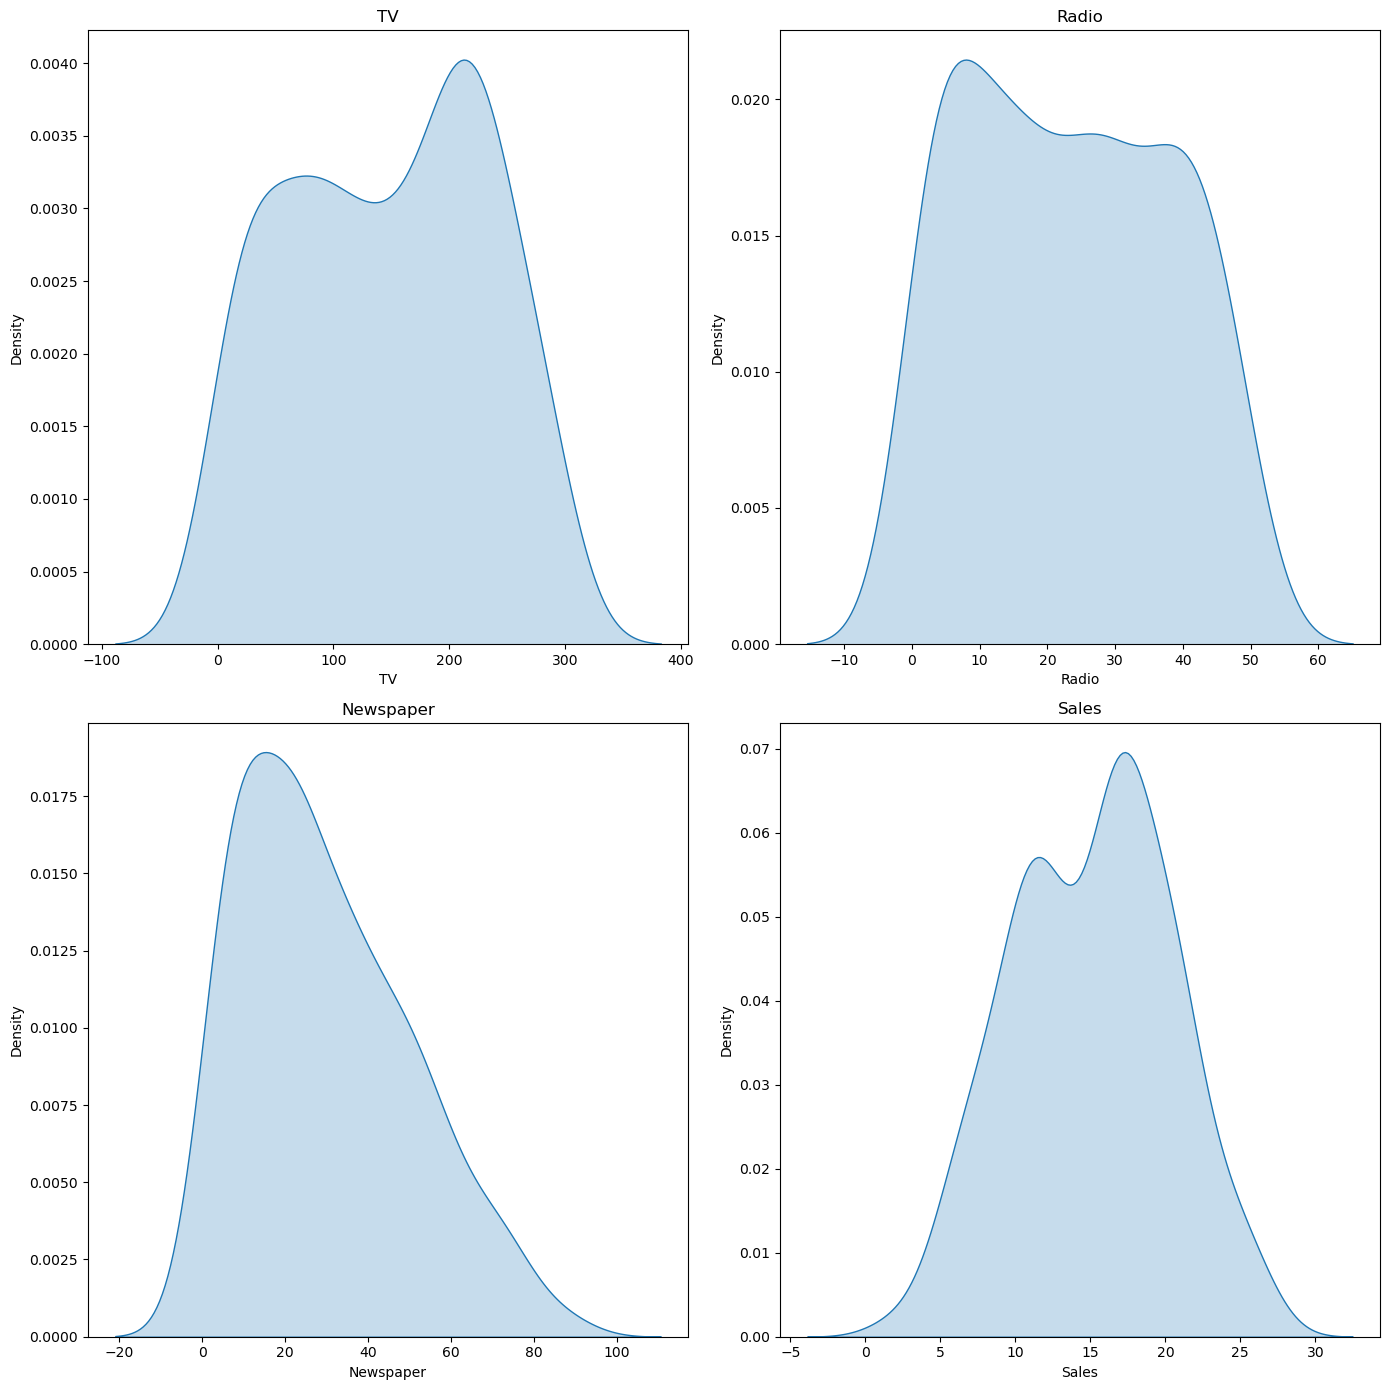

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(df.select_dtypes(include="number").columns):
    sns.kdeplot(data=df, x=col, ax=axes[i], fill=True)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# Feature Engineering

In [75]:
# Since all the colmuns are numerical, we don't need to encode.
# what we can do is : Create new feature like the total budget as the sum across columns. 
X = df[["Radio","Newspaper","TV"]]
X["budget"] = X.sum(axis=1, numeric_only=True)

In [77]:
X.drop(columns=["Radio", "Newspaper","TV"], inplace=True)
X.reset_index(drop=True, inplace=True)

In [79]:
print(X.sample(5))

     budget
16    376.8
4     250.0
160   232.1
80    280.8
67    275.9


In [84]:
y = df["Sales"]
y.sample(5)

102    20.7
26     20.9
156     7.3
153     3.2
9      15.6
Name: Sales, dtype: float64

In [87]:
# now let's scale X using standerisation.
# StandardScaler (zero mean, unit variance) the default for linear regression
# MinMaxScaler (0 to 1): Useful for bounded outu=put or the algorithm is sensitive to it.
# Important : Split then standarise.
# StandardScaler  comuputes the mean and std of the data we pass it. If we standarise before splitting, those statistics are "leaked" to the mean from the test set before evaluation.

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # Proportion of data for test set
    random_state=42     # Ensures reproducible results
)

print(f"x_train shape = {X_train.shape}")
print(f"x_test shape = {X_test.shape}")
print(f"y_train shape = {y_train.shape}")
print(f"y_test shape = {y_test.shape}")

x_train shape = (158, 1)
x_test shape = (40, 1)
y_train shape = (158,)
y_test shape = (40,)


In [90]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Model Training - Linear Regression

In [92]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train)

LinearRegression()

What did `.fit()` do ? LinearRegression uses the normal equation under the hood 
$w = (XᵀX)⁻¹ Xᵀy$. It computes the exact weights that minimize the sum of squared errors between predictions and actual values. No iterations, no learning rate but just one matrix operation. That's why there are no hyperparameters to tune in basic linear regression.

In [96]:
print(regressor.intercept_)   # the bias term (β₀)
print(regressor.coef_)        # one weight per feature

15.170886075949369
[4.88453796]


In [93]:
y_pred = regressor.predict(X_test_scaled)

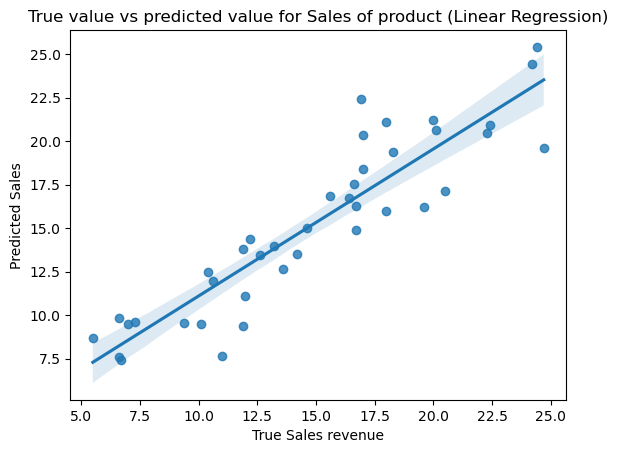

In [99]:
sns.regplot(x=y_test, y=y_pred)
plt.xlabel("True Sales revenue")
plt.ylabel("Predicted Sales")
plt.title("True value vs predicted value for Sales of product (Linear Regression)")
plt.show()

# Evaluation and valdiation

In [107]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Square Error= ", format(mse, ".4f"))
print(f"Mean Absolute Error: On average, the predictions are off by {mae:.4f} in sales")
print(f"RMSE: The prediction are off by ~{rmse:.4f} on average.")

print(f"R²: {r2:.4f}")


Mean Square Error=  4.7806
Mean Absolute Error: On average, the predictions are off by 1.7752 in sales
RMSE: The prediction are off by ~2.1865 on average.
R²: 0.8278


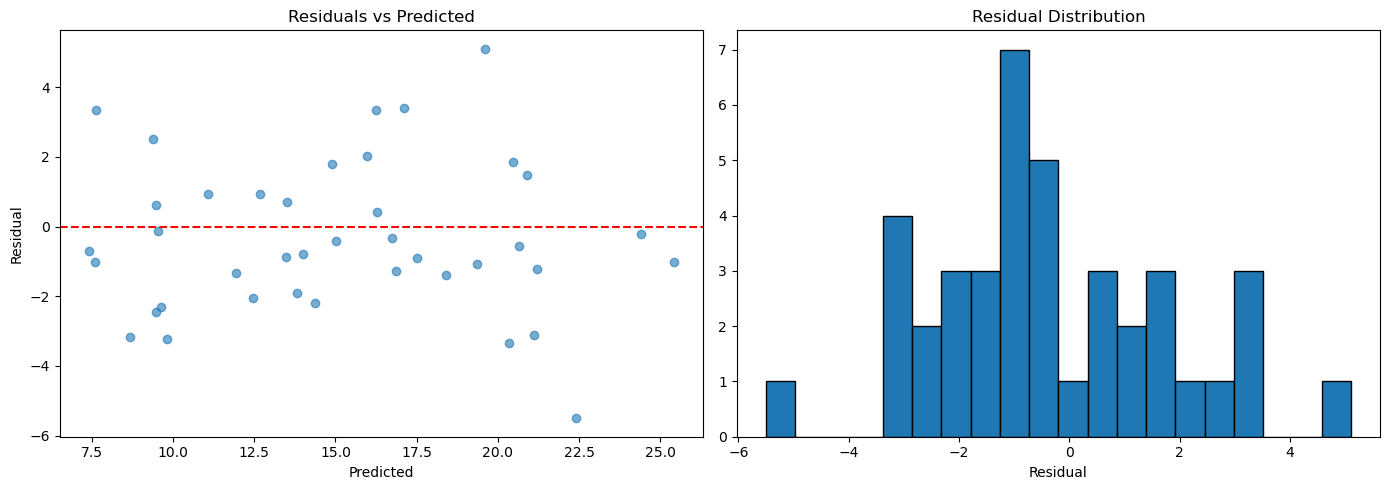

In [ ]:
# residual plot
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted — checks for patterns
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

# Distribution of residuals — checks normality assumption
axes[1].hist(residuals, bins=20, edgecolor="black")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

"""
- Left plot: residuals should scatter randomly around zero with no pattern. A curve or funnel shape means the model is systematically wrong somewhere.
- Right plot: should look roughly bell-shaped. Heavy skew means the normality assumption is violated.
"""

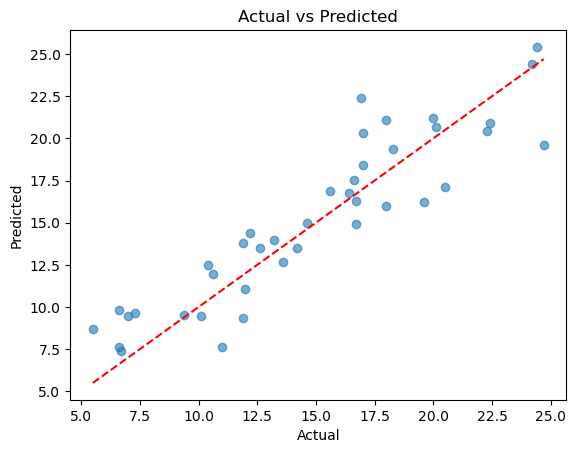

In [109]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()
